In [2]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch
import matplotlib.pyplot as plt

In [4]:
# Dataset
texts = ["I love this", "Worst product", "Amazing service", "Bad experience"]
labels = torch.tensor([1, 0, 1, 0])

# Tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")

In [5]:
# Model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased')

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

losses = []


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [8]:
# Training
for epoch in range(3):
    outputs = model(**inputs, labels=labels)
    loss = outputs.loss
    losses.append(loss.item())

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()


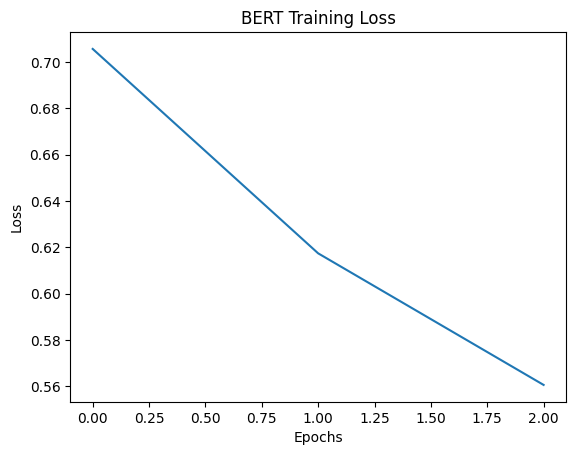

In [7]:
# Plot Loss
plt.plot(losses)
plt.title("BERT Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()